# Predictive Maintenance on the AI4I 2020 Dataset (Phase 1)
**Goal:** learn to predict when a machine fails, using sensor readings.
This is practice before we build the CT X-ray tube version.

**Plan:** load -> explore -> clean -> chart -> train 2 models -> compare -> save the best.

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Run this notebook from inside the notebooks/ folder
data = pd.read_csv("../data/ai4i2020.csv", encoding="utf-8-sig")  # utf-8-sig removes a hidden character at the file start
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Explore
How big is it, any missing values, and how rare are failures?

In [2]:
print("Rows, columns:", data.shape)
print("Missing values:", data.isna().sum().sum())
print()
print(data["Machine failure"].value_counts())
print(f"Failure rate: {data['Machine failure'].mean():.1%}")

Rows, columns: (10000, 14)
Missing values: 0

Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure rate: 3.4%


**What this tells us:** only about 3-4% of rows are failures. That is called *class imbalance*.
A lazy model that always says "no failure" would score ~96.6% accuracy while being useless.
So we must look at **recall** (of the real failures, how many did we catch?), not just accuracy.

## 2. Clean
Drop ID columns (they identify a row but say nothing about health). Drop the failure-type columns (TWF, HDF, PWF, OSF, RNF): they are the *reasons* for failure, so using them would be cheating. Turn the machine Type (L/M/H) into numbers.

In [3]:
clean = data.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])
clean = pd.get_dummies(clean, columns=["Type"], drop_first=True, dtype=int)
clean.columns = [c.split(" [")[0] for c in clean.columns]   # shorter names
clean.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


## 3. Visualise

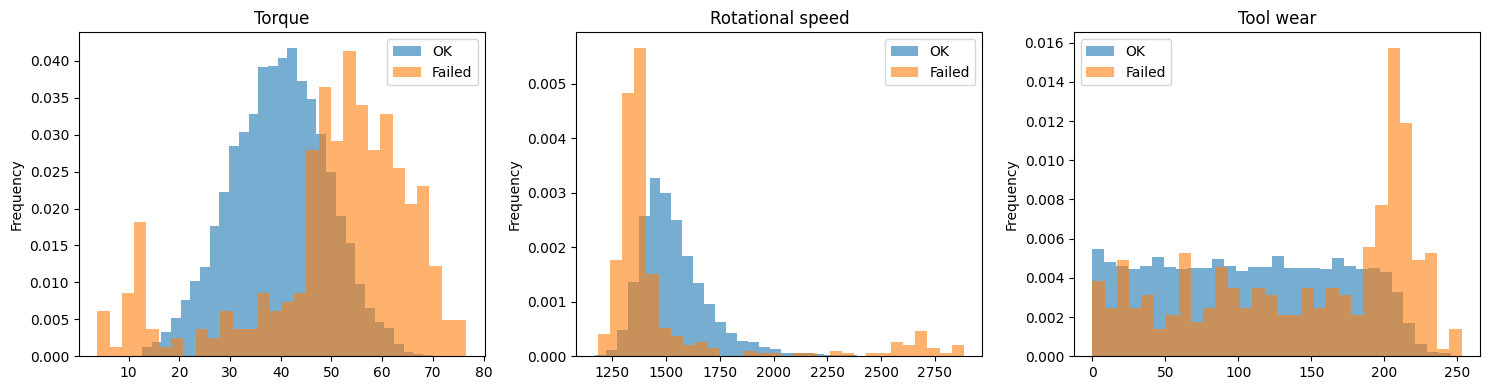

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Torque", "Rotational speed", "Tool wear"]):
    clean[clean["Machine failure"] == 0][col].plot.hist(bins=30, alpha=0.6, ax=ax, density=True, label="OK")
    clean[clean["Machine failure"] == 1][col].plot.hist(bins=30, alpha=0.6, ax=ax, density=True, label="Failed")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

**Reading the charts:** where the orange (failed) shape sits away from the blue (OK) shape, that sensor helps predict failure.
Failures tend to have higher torque and more tool wear.

## 4. Train two models
We hide 20% of the data to test on. `class_weight='balanced'` tells the models to treat rare failures as more important.

In [5]:
X = clean.drop(columns=["Machine failure"])
y = clean["Machine failure"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression needs sensors on a similar scale, so we add a scaler
logistic = make_pipeline(StandardScaler(),
                         LogisticRegression(class_weight="balanced", max_iter=1000))
forest = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)

logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 5. Compare

In [6]:
models = {"Logistic Regression": logistic, "Random Forest": forest}
rows = []
for name, m in models.items():
    guess = m.predict(X_test)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, guess),
                 "Precision": precision_score(y_test, guess),
                 "Recall": recall_score(y_test, guess),
                 "F1": f1_score(y_test, guess)})
results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.824,0.142,0.824,0.242
Random Forest,0.980,0.914,0.471,0.621


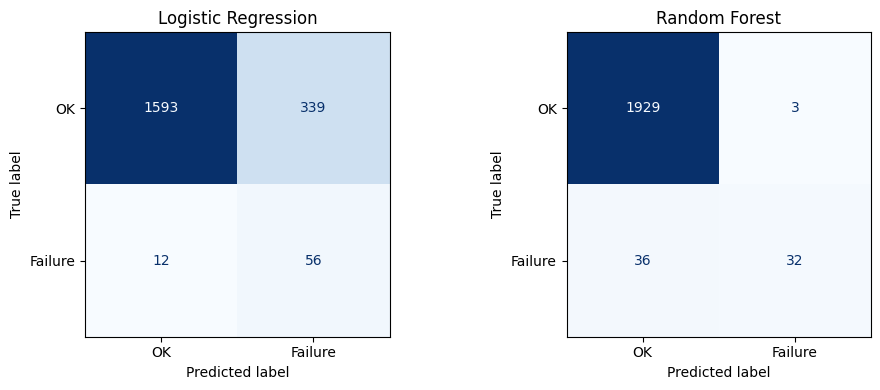

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test)),
                           display_labels=["OK", "Failure"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

**How to read the confusion matrix:** rows = what really happened, columns = what the model said.
Bottom-right = failures caught. Bottom-left = failures **missed** (the dangerous mistake).
Top-right = false alarms.

**Precision** = when the model says "failure", how often is it right?
**Recall** = of all real failures, how many did it catch?
**F1** = one number balancing both.

## 6. Save the best model
We pick the model with the higher F1 score (a fair balance of catching failures and avoiding false alarms).

In [8]:
best_name = results["F1"].idxmax()
print("Best model:", best_name)
joblib.dump(models[best_name], "../models/predictive_maintenance_model.pkl")
print("Saved ../models/predictive_maintenance_model.pkl")

Best model: Random Forest
Saved ../models/predictive_maintenance_model.pkl
